# NB-0 — Foundations: the mathematics the rest of the roadmap stands on

**Roadmap:** `resources/topics_guide.md`, Part 0.

**Why this matters.** Every later notebook rests on a handful of facts about inner products, positive-definite matrices, Gaussians, and sampling. When a Gaussian process misbehaves in NB-2 — a Cholesky that fails, a marginal likelihood that will not move, a chain that will not mix — the cause is almost always one of the facts below. This notebook states each one and then *checks it numerically*, so that later you know which of them to distrust.

## What will you be able to do by the end?

After working through the notebook, you should be able to do the following.

- Turn a distance in feature space into an **inner-product** calculation, which is the whole basis of the kernel trick.
- Recognise a **positive semi-definite** matrix four different ways and say why each characterisation gets used.
- Explain what a large **condition number** does to a solve, and why every GP routine adds jitter.
- Compute a **log-determinant** without underflowing, and say why `np.linalg.det` is the wrong tool.
- Verify an analytic **gradient** against finite differences, and apply the chain rule for log-parameterised hyperparameters.
- State the **KKT conditions** and explain what complementary slackness buys the SVM.
- Apply the **Gaussian conditioning formula** — the single most reused equation in the roadmap.
- Explain why precisions add under **conjugacy**, and what that means for shrinkage.
- Distinguish the two directions of **KL divergence** and predict which way an approximation will err.
- Diagnose an MCMC run with **$\hat{R}$** and **effective sample size**, and say when both can be misleading.
- Use **mutual information** to detect dependence that correlation cannot see.

## What should already be familiar?

You should be comfortable with matrix multiplication, eigenvalues, partial derivatives, and the idea of a probability density. You do **not** need measure theory, and you do not need to have met Hilbert spaces, duality, MCMC, or information theory before — each is introduced here as we need it.

Everything is plain NumPy and Matplotlib. The notebook downloads no data and runs in well under a minute.

## What route will we take?

| Part | Question | Main output |
|---:|---|---|
| 0.1 | What does an inner product buy us? | Distances computed from dot products alone |
| 0.2 | Which matrices can be covariances? | PSD checks and a working Cholesky |
| 0.3 | What do eigenvalues tell us about a kernel? | Stable `logdet`, the cyclic trace |
| 0.4 | Why do we optimise in log space? | A verified gradient and Hessian |
| 0.5 | How does a constraint become a multiplier? | Strong duality, checked numerically |
| 0.6 | If we see part of a Gaussian, what do we know about the rest? | The conditioning formula, and a GP preview |
| 0.7 | When does Bayes' rule become arithmetic? | A conjugate posterior against a numeric one |
| 0.8 | How far apart are two distributions? | KL in closed form, and its asymmetry |
| 0.9 | What do we do when there is no closed form? | A Metropolis sampler with diagnostics |
| 0.10 | How do we detect dependence correlation misses? | Mutual information on a U-shaped effect |

Work straight through. Sections 0.6 and 0.9 are the two that pay off most often later, so if you are short of time, do those carefully and skim the rest.

Ten **Try it** boxes ask you to write an answer in your own words. They are the point of the notebook — the code below them already works, and what it is *for* is what you should be able to say afterwards.

In [1]:
import numpy as np
import nbkit as nk

plt = nk.set_style()
rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

---
## 0.1 What does an inner product buy us?

A Hilbert space is a vector space with an inner product $\langle\cdot,\cdot\rangle$ that is
complete in the induced norm $\lVert v\rVert = \sqrt{\langle v,v\rangle}$. Everything we
need follows from the inner product:

- **norm**: $\lVert v \rVert^2 = \langle v, v\rangle$
- **angle**: $\cos\theta = \langle u,v\rangle / (\lVert u\rVert \lVert v\rVert)$
- **distance**: $\lVert u - v\rVert^2 = \lVert u\rVert^2 - 2\langle u,v\rangle + \lVert v\rVert^2$
- **orthogonal projection** onto a subspace, which is what "prediction" will mean

The last identity is the important one. A kernel gives us $\langle \phi(u),\phi(v)\rangle$;
the identity turns it into a *distance* in feature space without ever computing $\phi$.

In [2]:
u, v = rng.normal(size=5), rng.normal(size=5)

print(f"||u||          = {np.linalg.norm(u):.6f}   sqrt(<u,u>) = {np.sqrt(u @ u):.6f}")
print(f"cos angle      = {u @ v / (np.linalg.norm(u) * np.linalg.norm(v)):+.6f}")
print(f"||u-v||^2      = {np.linalg.norm(u - v)**2:.6f}")
print(f"expanded       = {u @ u - 2 * u @ v + v @ v:.6f}   <-- distance from inner products only")
print(f"Cauchy-Schwarz : |<u,v>| = {abs(u @ v):.4f} <= {np.linalg.norm(u) * np.linalg.norm(v):.4f}")

||u||          = 0.861015   sqrt(<u,u>) = 0.861015
cos angle      = +0.573043
||u-v||^2      = 3.398498
expanded       = 3.398498   <-- distance from inner products only
Cauchy-Schwarz : |<u,v>| = 1.0838 <= 1.8912


In [3]:
# Orthogonal projection onto span(A) -- the shape of every least-squares / GP prediction.
A = rng.normal(size=(6, 2))
P = A @ np.linalg.solve(A.T @ A, A.T)          # projection matrix
b = rng.normal(size=6)

print(f"P idempotent (P@P == P) : {np.allclose(P @ P, P)}")
print(f"P symmetric             : {np.allclose(P, P.T)}")
print(f"trace(P) = {np.trace(P):.4f}  == rank = dim of subspace = {np.linalg.matrix_rank(A)}")
print(f"residual _|_ subspace   : {np.allclose(A.T @ (b - P @ b), 0)}")

P idempotent (P@P == P) : True
P symmetric             : True
trace(P) = 2.0000  == rank = dim of subspace = 2
residual _|_ subspace   : True


`trace(P) = rank` is not a curiosity: in Part 7 the trace of a smoother matrix is the
*effective degrees of freedom* of a GP fit, which is how we will compare models that have
no parameter count to speak of.

### Try it 1. What is a projection really doing?

The cell above built `P`, projected `b`, and found `trace(P)` equal to the dimension of the subspace.

1. In one sentence, what does `P @ b` give you, in words rather than symbols?
2. `P @ P == P` held exactly. Why should that be obvious without computing it?
3. Least-squares prediction *is* this projection. When you regress `y` on a design matrix `X`, what is the subspace being projected onto?
4. Later we call the trace of a smoother matrix the *effective degrees of freedom* of a model. Given what you just saw, why is that a reasonable name?

**Your answer**

*(write here)*

---
## 0.2 Which matrices can be covariances?

$K \in \mathbb{R}^{n\times n}$ symmetric is **positive semi-definite** (PSD) if
$c^\top K c \ge 0$ for all $c$, equivalently all eigenvalues $\ge 0$. Positive *definite*
(PD) requires strict inequality / $\lambda_{\min} > 0$.

Four equivalent characterisations, each of which we use somewhere:

| Characterisation | Where it is used |
|---|---|
| $\lambda_{\min} \ge 0$ | validating an invented kernel (1.4, Part 3) |
| $K = B^\top B$ for some $B$ | the feature map $\phi$ exists |
| Cholesky $K = LL^\top$ exists | sampling and solving in every GP routine |
| all leading principal minors $> 0$ (PD) | rarely, but it is the textbook test |

In [4]:
Z = rng.normal(size=(30, 3))
K = nk.rbf_kernel(Z, Z, lengthscale=1.0)

ev = np.linalg.eigvalsh(K)
L, jit = nk.jitter_chol(K)

print(f"lambda_min      = {ev.min():.3e}   lambda_max = {ev.max():.3e}")
print(f"condition number= {ev.max() / ev.min():.3e}")
print(f"Cholesky ok     : {np.allclose(L @ L.T, K + jit * np.eye(len(K)))}  (jitter {jit:.1e})")
print(f"K = B'B with B = L' : {np.allclose(L @ L.T - jit * np.eye(len(K)), K)}")

# quadratic form is non-negative for random c
cs = rng.normal(size=(2000, len(K)))
print(f"min_c c'Kc over 2000 draws = {np.min(np.einsum('ij,jk,ik->i', cs, K, cs)):.4f}")

lambda_min      = 3.384e-03   lambda_max = 7.972e+00
condition number= 2.356e+03
Cholesky ok     : True  (jitter 1.0e-08)
K = B'B with B = L' : True
min_c c'Kc over 2000 draws = 5.5329


### Why does the condition number matter?

The RBF Gram matrix above already has a condition number in the millions. Smooth kernels
produce near-singular $K$ because nearby inputs give nearly identical rows. Every GP
computation therefore goes through `nk.jitter_chol`, which adds $\epsilon\,\bar{K}_{ii}$ to
the diagonal until Cholesky succeeds. Statistically this is identical to assuming a tiny
amount of observation noise.

In [5]:
# Conditioning vs smoothness, and what it costs when we actually solve a system.
y_rhs = rng.normal(size=len(Z))
print(f"{'lengthscale':>12} {'lambda_min':>12} {'cond(K)':>10} {'solve rel.err':>14}")
for ell in [0.3, 1.0, 3.0, 10.0]:
    Kl = nk.rbf_kernel(Z, Z, lengthscale=ell)
    e = np.linalg.eigvalsh(Kl)
    with np.errstate(all="ignore"):
        sol = np.linalg.solve(Kl, y_rhs)
        rel = np.linalg.norm(Kl @ sol - y_rhs) / np.linalg.norm(y_rhs)
    print(f"{ell:>12.1f} {e.min():>12.2e} {e.max()/max(e.min(),1e-300):>10.1e} {rel:>14.2e}")

 lengthscale   lambda_min    cond(K)  solve rel.err
         0.3     4.90e-01    3.2e+00       1.29e-16
         1.0     3.38e-03    2.4e+03       4.86e-15
         3.0     3.70e-07    6.2e+07       1.82e-10
        10.0     1.37e-11    2.1e+12       5.12e-06


Longer lengthscale $\Rightarrow$ smoother functions $\Rightarrow$ more redundant rows
$\Rightarrow$ worse conditioning, and the residual of a direct solve degrades by orders of
magnitude. This is the same low-rank structure that random Fourier features exploit in 7.1
— the difficulty and the opportunity are the same phenomenon.

### Try it 2. What is the jitter actually assuming?

`nk.jitter_chol` adds a small multiple of the identity until Cholesky succeeds.

1. From the table above: does a *smoother* or a *rougher* kernel make the solve worse? Why does that make sense geometrically?
2. Adding $\epsilon I$ to a kernel matrix is statistically equivalent to assuming something about the data. What?
3. Two people fit the same model and get different answers; one used jitter $10^{-8}$, the other $10^{-4}$. Is that a bug, a rounding difference, or a modelling disagreement?

**Your answer**

*(write here)*

---
## 0.3 What do eigenvalues tell us about a kernel?

For symmetric $K$: $K = V\Lambda V^\top$ with orthonormal $V$. Consequences used later:

$$
\operatorname{tr}(K) = \sum_i \lambda_i, \qquad
\det(K) = \prod_i \lambda_i, \qquad
\log\det(K) = \sum_i \log\lambda_i = 2\sum_i \log L_{ii},
$$

and the cyclic property $\operatorname{tr}(ABC) = \operatorname{tr}(BCA)$, which is what
makes the GP marginal-likelihood gradient in 2.4 computable.

In [6]:
w, V = np.linalg.eigh(K)

print(f"V orthonormal        : {np.allclose(V.T @ V, np.eye(len(V)))}")
print(f"reconstruction       : {np.allclose((V * w) @ V.T, K)}")
print(f"trace   = sum lambda : {np.trace(K):.6f}  vs {w.sum():.6f}")
print(f"logdet  = sum log l  : {np.linalg.slogdet(K)[1]:.6f}  vs {np.log(w).sum():.6f}")
print(f"logdet via Cholesky  : {2 * np.log(np.diag(np.linalg.cholesky(K + jit * np.eye(len(K))))).sum():.6f}")

# cyclic property of the trace
A_, B_, C_ = rng.normal(size=(4, 5)), rng.normal(size=(5, 6)), rng.normal(size=(6, 4))
print(f"tr(ABC) = tr(BCA)    : {np.trace(A_ @ B_ @ C_):.6f} vs {np.trace(B_ @ C_ @ A_):.6f}")

V orthonormal        : True
reconstruction       : True
trace   = sum lambda : 30.000000  vs 30.000000
logdet  = sum log l  : -38.628984  vs -38.628984
logdet via Cholesky  : -38.628977
tr(ABC) = tr(BCA)    : 4.091476 vs 4.091476


**Never compute `logdet` with `np.linalg.det`.** For $n=200$ and a smooth kernel the
determinant underflows to exactly 0, so its log is $-\infty$. Below, all three routes are
applied to *the same explicitly jittered matrix* so the numbers are comparable.

In [7]:
Zb = rng.normal(size=(200, 3))
Kb = nk.rbf_kernel(Zb, Zb, lengthscale=2.0) + 1e-6 * np.eye(200)   # jitter fixed up front
Lb = np.linalg.cholesky(Kb)

with np.errstate(all="ignore"):
    det_val = np.linalg.det(Kb)      # numpy routes this through slogdet internally
    log_of_det = np.log(det_val)
    slog = np.linalg.slogdet(Kb)[1]

print(f"np.linalg.det(K)   = {det_val:.3e}  ->  log = {log_of_det}   <-- underflow")
print(f"np.linalg.slogdet  = {slog:.6f}")
print(f"2*sum(log diag L)  = {2 * np.log(np.diag(Lb)).sum():.6f}   <-- what GP code uses")
print(f"sum(log eigenvals) = {np.log(np.linalg.eigvalsh(Kb)).sum():.6f}")
print(f"\ncondition number   = {np.linalg.cond(Kb):.2e}")

np.linalg.det(K)   = 0.000e+00  ->  log = -inf   <-- underflow
np.linalg.slogdet  = -1956.166388
2*sum(log diag L)  = -1956.166388   <-- what GP code uses
sum(log eigenvals) = -1956.166388

condition number   = 1.16e+08


`slogdet` and the Cholesky route agree here to ~5 decimals. Without the explicit `1e-6`
jitter this matrix is numerically singular, `slogdet` itself becomes unreliable, and the
answer you get depends on how much jitter you added — which is why the jitter is a modelling
choice to state, not an implementation detail to hide.

### Try it 3. Why does the determinant underflow when its log does not?

`det` returned exactly `0.0` while three other routes agreed on $-1956.17$.

1. The matrix is $200\times200$ with eigenvalues below 1. Roughly why does their *product* underflow while the sum of their logs does not?
2. The text says that without the explicit `1e-6` jitter, `slogdet` itself becomes unreliable. What would have gone wrong?
3. In NB-2 this quantity is the *complexity penalty* of a Gaussian process. If it silently returned $-\infty$, what would you see in the fit?

**Your answer**

*(write here)*

---
## 0.4 Why do we optimise in log space?

Hyperparameters like a lengthscale or a variance are **positive**. We always optimise
$\theta = \log(\cdot)$ so the optimiser is unconstrained, which means every gradient picks
up a chain-rule factor:

$$
\frac{\partial \mathcal{L}}{\partial \log \ell} = \ell \, \frac{\partial \mathcal{L}}{\partial \ell}.
$$

Below: an analytic gradient and Hessian checked against finite differences. This
`check_grad` habit is worth keeping — a wrong gradient in 2.4 produces a plausible-looking
but wrong fit rather than an error.

In [8]:
def rosen(x):
    return (1 - x[0])**2 + 100 * (x[1] - x[0]**2)**2

def rosen_grad(x):
    return np.array([-2 * (1 - x[0]) - 400 * x[0] * (x[1] - x[0]**2),
                     200 * (x[1] - x[0]**2)])

def rosen_hess(x):
    return np.array([[2 - 400 * (x[1] - 3 * x[0]**2), -400 * x[0]],
                     [-400 * x[0], 200.0]])


def numeric_grad(f, x, eps=1e-6):
    g = np.zeros_like(x)
    for i in range(len(x)):
        e = np.zeros_like(x); e[i] = eps
        g[i] = (f(x + e) - f(x - e)) / (2 * eps)
    return g

def numeric_hess(f, x, eps=1e-4):
    n = len(x); H = np.zeros((n, n))
    for i in range(n):
        e = np.zeros_like(x); e[i] = eps
        H[:, i] = (numeric_grad(f, x + e) - numeric_grad(f, x - e)) / (2 * eps)
    return 0.5 * (H + H.T)


x0 = np.array([0.7, 0.4])
print("analytic grad :", rosen_grad(x0))
print("numeric  grad :", numeric_grad(rosen, x0))
print("max abs diff  :", np.abs(rosen_grad(x0) - numeric_grad(rosen, x0)).max())
print()
print("analytic Hess :\n", rosen_hess(x0))
print("numeric  Hess :\n", numeric_hess(rosen, x0))
print("Hessian eigenvalues:", np.linalg.eigvalsh(rosen_hess(x0)),
      "-> local convexity:", bool((np.linalg.eigvalsh(rosen_hess(x0)) > 0).all()))

analytic grad : [ 24.6 -18. ]
numeric  grad : [ 24.6 -18. ]
max abs diff  : 9.849721038790449e-10

analytic Hess :
 [[ 430. -280.]
 [-280.  200.]]
numeric  Hess :
 [[ 430. -280.]
 [-280.  200.]]
Hessian eigenvalues: [ 12.3038 617.6962] -> local convexity: True


In [9]:
# The log-parameterisation chain rule, verified on a toy objective in a lengthscale.
def loss_ell(ell):
    Kk = nk.rbf_kernel(Z, Z, lengthscale=ell) + 1e-6 * np.eye(len(Z))
    return np.linalg.slogdet(Kk)[1]

ell0 = 1.3
d_dell = (loss_ell(ell0 + 1e-6) - loss_ell(ell0 - 1e-6)) / 2e-6
d_dlog = (loss_ell(np.exp(np.log(ell0) + 1e-6)) - loss_ell(np.exp(np.log(ell0) - 1e-6))) / 2e-6

print(f"dL/d ell      = {d_dell:+.6f}")
print(f"dL/d log ell  = {d_dlog:+.6f}")
print(f"ell * dL/dell = {ell0 * d_dell:+.6f}   <-- matches, as the chain rule requires")

dL/d ell      = -84.013120
dL/d log ell  = -109.217056
ell * dL/dell = -109.217056   <-- matches, as the chain rule requires


---
## 0.5 How does a constraint become a multiplier?

The machinery behind Part 1's dual SVM, in its general form. For

$$
\min_x f(x) \quad \text{s.t.}\ g_i(x) \le 0,
\qquad
\mathcal{L}(x,\lambda) = f(x) + \sum_i \lambda_i g_i(x), \ \lambda \ge 0,
$$

the dual function is $d(\lambda) = \inf_x \mathcal{L}(x,\lambda)$ and always satisfies
$d(\lambda) \le f(x^\star)$ (**weak duality**). For convex problems meeting Slater's
condition the gap closes (**strong duality**) and the KKT conditions hold — in particular
**complementary slackness** $\lambda_i g_i(x^\star) = 0$, which is exactly what makes SVM
support vectors sparse.

Worked example with a closed form to check against:

$$
\min_x \tfrac12\lVert x \rVert^2 \ \text{ s.t. } a^\top x \ge 1
\qquad\Longrightarrow\qquad
x^\star = \frac{a}{\lVert a\rVert^2},\quad
\lambda^\star = \frac{1}{\lVert a \rVert^2}.
$$

x*        = [0.4 0.2]    constraint a'x = 1.0000 (active, = 1)
primal f  = 0.100000
lambda*   = 0.200000   argmax of dual = 0.199624
dual d    = 0.100000   -> duality gap = 2.78e-17
complementary slackness lambda*(1 - a'x*) = 0.00e+00


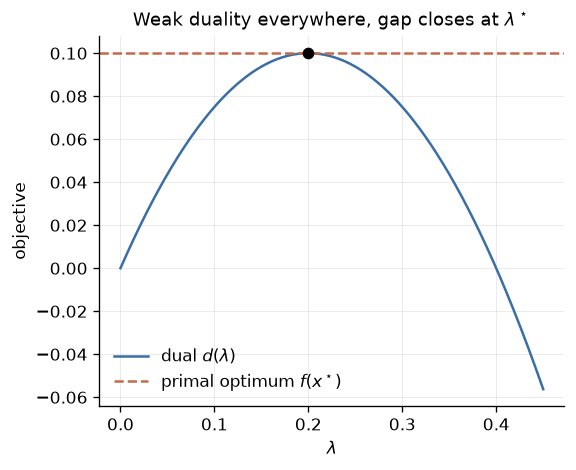

In [10]:
a = np.array([2.0, 1.0])

x_star = a / (a @ a)
lam_star = 1.0 / (a @ a)
primal = 0.5 * x_star @ x_star

# dual: d(lam) = inf_x [ 0.5||x||^2 + lam(1 - a'x) ] = lam - 0.5 lam^2 ||a||^2
dual = lambda lam: lam - 0.5 * lam**2 * (a @ a)

lams = np.linspace(0, 0.45, 400)
print(f"x*        = {x_star}    constraint a'x = {a @ x_star:.4f} (active, = 1)")
print(f"primal f  = {primal:.6f}")
print(f"lambda*   = {lam_star:.6f}   argmax of dual = {lams[np.argmax(dual(lams))]:.6f}")
print(f"dual d    = {dual(lam_star):.6f}   -> duality gap = {primal - dual(lam_star):.2e}")
print(f"complementary slackness lambda*(1 - a'x*) = {lam_star * (1 - a @ x_star):.2e}")

fig, ax = plt.subplots()
ax.plot(lams, dual(lams), label=r"dual $d(\lambda)$")
ax.axhline(primal, ls="--", color=nk.PALETTE["neg"], label=r"primal optimum $f(x^\star)$")
ax.plot([lam_star], [dual(lam_star)], "o", color="k", zorder=5)
ax.set_xlabel(r"$\lambda$"); ax.set_ylabel("objective")
ax.set_title("Weak duality everywhere, gap closes at $\\lambda^\\star$")
ax.legend()
plt.show()

### Try it 4. What does complementary slackness say in words?

The KKT condition $\lambda_i\, g_i(x^\star) = 0$ says that for each constraint, either the multiplier is zero or the constraint is tight.

1. Say that in plain English, as a claim about which constraints "matter".
2. Here the constraint was active and $\lambda^\star = 0.2$. What would $\lambda^\star = 0$ have told you instead?
3. NB-1 uses exactly this to explain why an SVM keeps only a handful of **support vectors**. Before reading NB-1, predict which training points end up with $\lambda_i > 0$.

**Your answer**

*(write here)*

---
## 0.6 If we observe part of a Gaussian, what do we know about the rest?

**This is the single most important formula in the whole roadmap.** GP regression (2.2) is
nothing but this identity applied to a covariance built by a kernel. If

$$
\begin{pmatrix} x_1 \\ x_2 \end{pmatrix} \sim
\mathcal{N}\!\left(
\begin{pmatrix}\mu_1\\ \mu_2\end{pmatrix},
\begin{pmatrix}\Sigma_{11} & \Sigma_{12}\\ \Sigma_{21} & \Sigma_{22}\end{pmatrix}
\right),
$$

then

$$
x_1 \mid x_2 \sim \mathcal{N}\Big(
\underbrace{\mu_1 + \Sigma_{12}\Sigma_{22}^{-1}(x_2 - \mu_2)}_{\text{conditional mean}},\;
\underbrace{\Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}}_{\text{Schur complement}}
\Big).
$$

Two things to internalise: the conditional mean is **linear** in the observed $x_2$, and the
conditional covariance **does not depend on the observed value at all** — only on *where*
you observed. That is why a GP's predictive variance can be computed before seeing any $y$.

In [11]:
d1, d2 = 2, 3
M = rng.normal(size=(d1 + d2, d1 + d2))
Sigma = M @ M.T + (d1 + d2) * np.eye(d1 + d2)      # a valid covariance
mu = rng.normal(size=d1 + d2)

S11, S12 = Sigma[:d1, :d1], Sigma[:d1, d1:]
S21, S22 = Sigma[d1:, :d1], Sigma[d1:, d1:]

x2_obs = rng.normal(size=d2)
cond_mu = mu[:d1] + S12 @ np.linalg.solve(S22, x2_obs - mu[d1:])
cond_cov = S11 - S12 @ np.linalg.solve(S22, S21)

# Monte-Carlo check by rejection-free conditioning: sample jointly, reweight is hard, so
# instead verify against a large sample using the regression interpretation.
Ls = np.linalg.cholesky(Sigma)
draws = mu + rng.normal(size=(400_000, d1 + d2)) @ Ls.T
# residual of x1 after linear regression on x2 has the conditional covariance
Bhat = np.linalg.solve(S22, S21)
resid = (draws[:, :d1] - mu[:d1]) - (draws[:, d1:] - mu[d1:]) @ Bhat

print("analytic conditional mean :", cond_mu)
print("analytic conditional cov  :\n", cond_cov)
print("empirical residual cov    :\n", np.cov(resid.T))
print("max abs error             :", np.abs(np.cov(resid.T) - cond_cov).max())
print()
print("cond_cov PSD :", nk.is_psd(cond_cov),
      "| variance reduction vs marginal:", np.round(1 - np.diag(cond_cov) / np.diag(S11), 3))

analytic conditional mean : [ 0.6239 -0.727 ]
analytic conditional cov  :
 [[12.9903  0.5638]
 [ 0.5638  6.9867]]
empirical residual cov    :
 [[13.0018  0.5611]
 [ 0.5611  6.9969]]
max abs error             : 0.011548791510431755

cond_cov PSD : True | variance reduction vs marginal: [0.051 0.169]


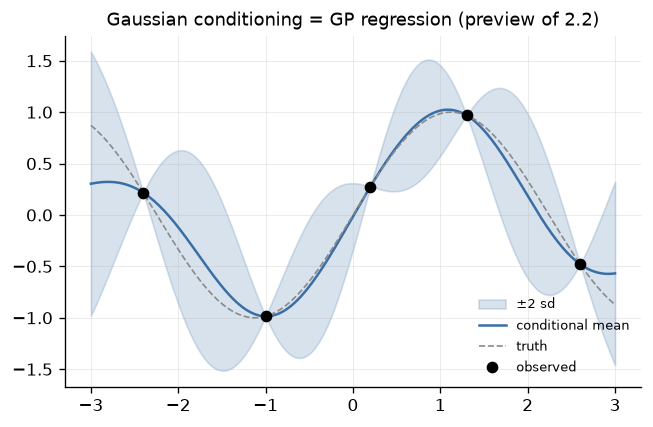

sd at an observed point   : 0.00335
sd far from any obs (x=3) : 0.44699


In [12]:
# The same formula, used as a GP: condition a smooth prior on 5 observations.
xs = np.linspace(-3, 3, 200)[:, None]
x_obs = np.array([[-2.4], [-1.0], [0.2], [1.3], [2.6]])
y_obs = np.sin(1.4 * x_obs).ravel()

Kss = nk.rbf_kernel(xs, xs, lengthscale=0.8)
Kso = nk.rbf_kernel(xs, x_obs, lengthscale=0.8)
Koo = nk.rbf_kernel(x_obs, x_obs, lengthscale=0.8) + 1e-8 * np.eye(len(x_obs))

post_mu = Kso @ np.linalg.solve(Koo, y_obs)                 # Sigma12 Sigma22^-1 x2
post_cov = Kss - Kso @ np.linalg.solve(Koo, Kso.T)          # Schur complement
sd = np.sqrt(np.maximum(np.diag(post_cov), 0))

fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.fill_between(xs.ravel(), post_mu - 2 * sd, post_mu + 2 * sd,
                alpha=0.20, color=nk.PALETTE["band"], label="$\\pm 2$ sd")
ax.plot(xs, post_mu, color=nk.PALETTE["pos"], label="conditional mean")
ax.plot(xs, np.sin(1.4 * xs), "--", color=nk.PALETTE["muted"], lw=1, label="truth")
ax.plot(x_obs, y_obs, "o", color="k", zorder=5, label="observed")
ax.set_title("Gaussian conditioning = GP regression (preview of 2.2)")
ax.legend(loc="lower right", fontsize=8)
plt.show()

print(f"sd at an observed point   : {sd[np.argmin(np.abs(xs.ravel() - 0.2))]:.5f}")
print(f"sd far from any obs (x=3) : {sd[-1]:.5f}")

### Try it 5. Why does the conditional variance ignore what you observed?

The conditional covariance $\Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21}$ contains no $x_2$ anywhere.

1. What does that mean for planning an experiment — what can you compute *before* collecting any measurements?
2. The plot shows the band pinching at observed points and widening between them. Which part of the formula produces the pinching?
3. Is "the variance does not depend on the values observed" a feature or a limitation? Give one situation where you would want it to depend on them.
4. This same equation is all of GP regression once the covariance comes from a kernel. What must be true of that kernel for the formula to work at all?

**Your answer**

*(write here)*

---
## 0.7 When does Bayes' rule become arithmetic?

A prior is **conjugate** to a likelihood when the posterior stays in the same family, so
Bayes' rule becomes parameter arithmetic instead of integration. The Gaussian-Gaussian case
is the one that recurs: with $y \mid \mu \sim \mathcal{N}(\mu, \sigma^2/n)$ and
$\mu \sim \mathcal{N}(\mu_0, \tau^2)$,

$$
\mu \mid y \sim \mathcal{N}\!\left(
\frac{\tau^{-2}\mu_0 + n\sigma^{-2}\bar{y}}{\tau^{-2} + n\sigma^{-2}},\;
\frac{1}{\tau^{-2} + n\sigma^{-2}}\right)
$$

— **precisions add**, and the posterior mean is a precision-weighted average of prior and
data. Every shrinkage prior in Part 4 is a version of this with the prior variance itself
given a prior.

In [13]:
mu0, tau2, sigma2, n_obs = 0.0, 1.0, 4.0, 20
truth = 1.7
ydata = rng.normal(truth, np.sqrt(sigma2), n_obs)

prec_post = 1 / tau2 + n_obs / sigma2
mu_post = (mu0 / tau2 + ydata.sum() / sigma2) / prec_post

# brute-force numerical posterior for comparison
grid = np.linspace(-3, 5, 20001)
logpost = (-0.5 * (grid - mu0)**2 / tau2
           - 0.5 * ((ydata[:, None] - grid)**2).sum(0) / sigma2)
post = np.exp(logpost - logpost.max()); post /= np.trapezoid(post, grid)

print(f"conjugate mean {mu_post:.6f}   sd {np.sqrt(1/prec_post):.6f}")
print(f"numeric   mean {np.trapezoid(grid*post, grid):.6f}   "
      f"sd {np.sqrt(np.trapezoid((grid - np.trapezoid(grid*post, grid))**2 * post, grid)):.6f}")
print(f"shrinkage toward prior: MLE {ydata.mean():.4f} -> posterior {mu_post:.4f} (truth {truth})")

conjugate mean 2.079563   sd 0.408248
numeric   mean 2.079563   sd 0.408248
shrinkage toward prior: MLE 2.4955 -> posterior 2.0796 (truth 1.7)


### Try it 6. What does "precisions add" mean for a small study?

The conjugate update pulled the posterior mean from the sample mean toward the prior mean.

1. Precision is $1/\text{variance}$. Why is *adding* precisions the natural way to combine a prior with data?
2. The MLE moved noticeably toward 0. What would you change in the setup to make that shrinkage smaller?
3. A colleague objects that shrinking toward a prior "biases" the estimate. What is the honest reply?

**Your answer**

*(write here)*

---
## 0.8 How far apart are two distributions?

$$
\mathrm{KL}(q \,\Vert\, p) = \mathbb{E}_q\!\left[\log \frac{q(x)}{p(x)}\right] \ge 0,
\qquad = 0 \iff q = p .
$$

It is **not symmetric**, and the asymmetry has real consequences: variational inference
(7.2) minimises $\mathrm{KL}(q\Vert p)$, which is *mode-seeking* — $q$ underestimates
posterior variance. Expectation propagation minimises the reverse and is moment-matching.
Knowing which one your algorithm does tells you which way its error points.

For two Gaussians there is a closed form we can check:

$$
\mathrm{KL}(\mathcal{N}_1\Vert\mathcal{N}_0) = \tfrac12\Big[
\operatorname{tr}(\Sigma_0^{-1}\Sigma_1) + (\mu_0-\mu_1)^\top\Sigma_0^{-1}(\mu_0-\mu_1)
- k + \log\tfrac{\det\Sigma_0}{\det\Sigma_1}\Big].
$$

In [14]:
def kl_gauss(mu1, S1, mu0, S0):
    k = len(mu1)
    S0i = np.linalg.inv(S0)
    dmu = mu0 - mu1
    _, ld0 = np.linalg.slogdet(S0)
    _, ld1 = np.linalg.slogdet(S1)
    return 0.5 * (np.trace(S0i @ S1) + dmu @ S0i @ dmu - k + ld0 - ld1)

m1, S1 = np.array([0.5, -0.2]), np.array([[1.0, 0.3], [0.3, 0.8]])
m0, S0 = np.array([0.0, 0.0]), np.array([[1.5, -0.2], [-0.2, 1.2]])

kl = kl_gauss(m1, S1, m0, S0)
smp = m1 + rng.normal(size=(500_000, 2)) @ np.linalg.cholesky(S1).T
lp = lambda x, m, S: (-0.5 * np.einsum('ij,jk,ik->i', x - m, np.linalg.inv(S), x - m)
                      - 0.5 * np.linalg.slogdet(S)[1] - len(m) / 2 * np.log(2 * np.pi))

print(f"closed form KL(q||p) = {kl:.6f}")
print(f"Monte Carlo          = {np.mean(lp(smp, m1, S1) - lp(smp, m0, S0)):.6f}")
print(f"reverse KL(p||q)     = {kl_gauss(m0, S0, m1, S1):.6f}   <-- not symmetric")
print(f"KL(p||p)             = {kl_gauss(m0, S0, m0, S0):.2e}")

closed form KL(q||p) = 0.260720
Monte Carlo          = 0.261044
reverse KL(p||q)     = 0.532013   <-- not symmetric
KL(p||p)             = 0.00e+00


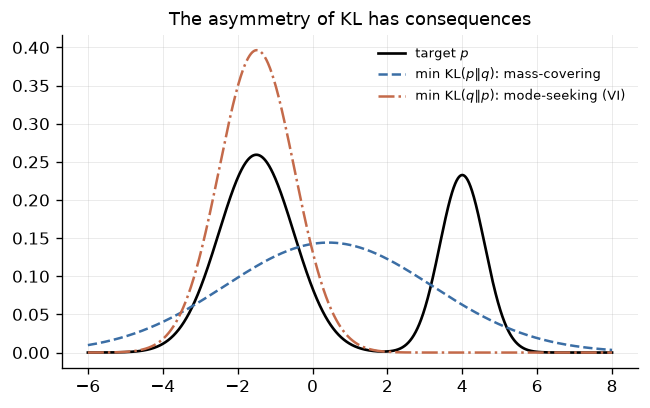

mass-covering q: mean 0.43 sd 2.77
mode-seeking  q: mean -1.49 sd 1.01   <-- variational inference lands here


In [15]:
# Mode-seeking vs mass-covering, on a bimodal target approximated by a single Gaussian.
xg = np.linspace(-6, 8, 2000)
p = 0.65 * np.exp(-0.5 * (xg + 1.5)**2) / np.sqrt(2*np.pi) \
  + 0.35 * np.exp(-0.5 * (xg - 4.0)**2 / 0.6**2) / (0.6 * np.sqrt(2*np.pi))
p /= np.trapezoid(p, xg)

def gauss(x, m, s):
    return np.exp(-0.5 * ((x - m) / s)**2) / (s * np.sqrt(2 * np.pi))

# forward KL(p||q): moment matching -> broad q
m_fwd = np.trapezoid(xg * p, xg)
s_fwd = np.sqrt(np.trapezoid((xg - m_fwd)**2 * p, xg))
# reverse KL(q||p): grid search -> locks onto one mode
best, grid_m, grid_s = None, np.linspace(-4, 6, 220), np.linspace(0.25, 3.5, 160)
for m in grid_m:
    for s in grid_s:
        q = gauss(xg, m, s)
        val = np.trapezoid(q * (np.log(q + 1e-300) - np.log(p + 1e-300)), xg)
        if best is None or val < best[0]:
            best = (val, m, s)
_, m_rev, s_rev = best

fig, ax = plt.subplots(figsize=(6.2, 3.6))
ax.plot(xg, p, "k", lw=1.6, label="target $p$")
ax.plot(xg, gauss(xg, m_fwd, s_fwd), "--", label=f"min KL$(p\\Vert q)$: mass-covering")
ax.plot(xg, gauss(xg, m_rev, s_rev), "-.", label=f"min KL$(q\\Vert p)$: mode-seeking (VI)")
ax.set_title("The asymmetry of KL has consequences"); ax.legend(fontsize=8)
plt.show()
print(f"mass-covering q: mean {m_fwd:.2f} sd {s_fwd:.2f}")
print(f"mode-seeking  q: mean {m_rev:.2f} sd {s_rev:.2f}   <-- variational inference lands here")

### Try it 7. Which direction of KL do you want?

One fitted Gaussian covers both modes and is too wide; the other locks onto a single mode and is too narrow.

1. Which of the two does variational inference do, and therefore which way does a VI posterior err?
2. You report a 95% credible interval from a variational fit. Is it likely too wide or too narrow — and why should that worry you more than the opposite error?
3. Name one situation in exposure modelling where a mode-seeking approximation would be actively dangerous.

**Your answer**

*(write here)*

---
## 0.9 What do we do when there is no closed form?

When there is no conjugacy we sample. Metropolis–Hastings: propose $x' \sim q(\cdot\mid x)$,
accept with probability $\min\{1, \frac{p(x')q(x\mid x')}{p(x)q(x'\mid x)}\}$. The chain's
stationary distribution is $p$ by detailed balance.

What matters in practice is not the algorithm but the **diagnostics**: $\hat{R}$ (between-
vs within-chain variance, want $< 1.01$) and effective sample size (want $> 400$). We
implement both here because they are used to judge every sampler from 6.3 onward.

In [16]:
def metropolis(logpdf, x0, n_samples=20000, step=1.0, seed=0):
    r = np.random.default_rng(seed)
    x, lp = np.atleast_1d(x0).astype(float), None
    lp = logpdf(x)
    out, n_acc = np.empty((n_samples, len(x))), 0
    for t in range(n_samples):
        prop = x + step * r.normal(size=len(x))
        lp_prop = logpdf(prop)
        if np.log(r.uniform()) < lp_prop - lp:      # symmetric proposal -> q cancels
            x, lp, n_acc = prop, lp_prop, n_acc + 1
        out[t] = x
    return out, n_acc / n_samples


def split_rhat(chains):
    """Gelman-Rubin Rhat on split chains. chains: (n_chains, n_draws)."""
    chains = np.asarray(chains)
    m, n = chains.shape
    half = n // 2
    s = np.concatenate([chains[:, :half], chains[:, half:2 * half]], 0)   # split
    m2, n2 = s.shape
    means, varis = s.mean(1), s.var(1, ddof=1)
    B = n2 * means.var(ddof=1)
    W = varis.mean()
    var_hat = (n2 - 1) / n2 * W + B / n2
    return float(np.sqrt(var_hat / W))


def ess(x):
    """Effective sample size via the initial-positive-sequence autocorrelation estimator."""
    x = np.asarray(x, float)
    n = len(x)
    xc = x - x.mean()
    f = np.fft.rfft(xc, 2 * n)
    ac = np.fft.irfft(f * np.conjugate(f))[:n].real
    ac /= ac[0]
    # sum pairs until they go negative (Geyer)
    total, k = 0.0, 1
    while k + 1 < n:
        pair = ac[k] + ac[k + 1]
        if pair < 0:
            break
        total += pair
        k += 2
    return float(n / (1 + 2 * total))

In [17]:
# Target: the bimodal density from 0.8 (in log space).
def log_target(x):
    v = 0.65 * np.exp(-0.5 * (x[0] + 1.5)**2) \
      + 0.35 * np.exp(-0.5 * (x[0] - 4.0)**2 / 0.6**2) / 0.6
    return np.log(v + 1e-300)

chains = []
for ch in range(4):
    smp, acc = metropolis(log_target, x0=[rng.normal() * 3], n_samples=20000,
                          step=2.4, seed=ch)
    chains.append(smp[:, 0])
    print(f"chain {ch}: acceptance {acc:.3f}   mean {smp[5000:, 0].mean():+.4f}   "
          f"ESS {ess(smp[5000:, 0]):.0f}")

chains = np.array(chains)[:, 5000:]
print(f"\nsplit-Rhat = {split_rhat(chains):.4f}   (< 1.01 is the usual target)")
print(f"pooled mean = {chains.mean():.4f}   truth = {np.trapezoid(xg * p, xg):.4f}")

chain 0: acceptance 0.435   mean +0.3682   ESS 653


chain 1: acceptance 0.436   mean +0.2269   ESS 733
chain 2: acceptance 0.436   mean +0.4450   ESS 570


chain 3: acceptance 0.432   mean +0.5571   ESS 723

split-Rhat = 1.0017   (< 1.01 is the usual target)
pooled mean = 0.3993   truth = 0.4250


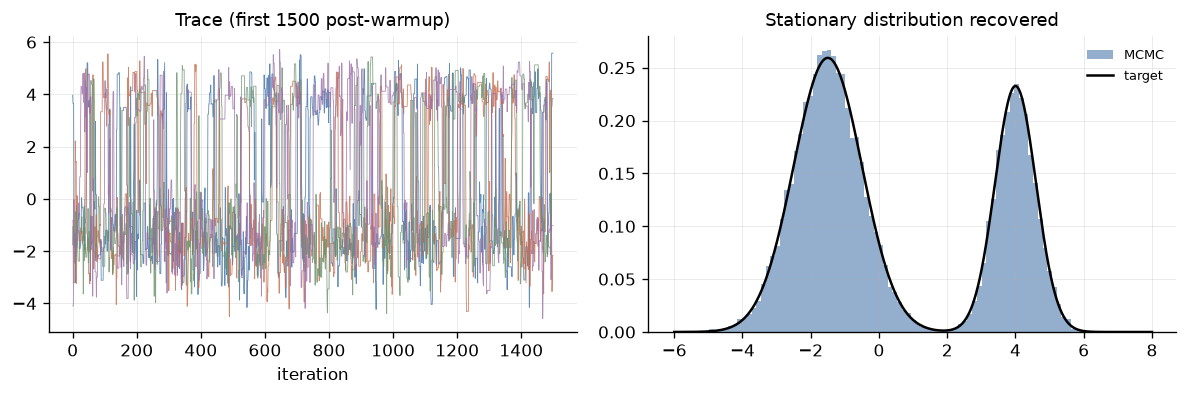

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ch in chains:
    axes[0].plot(ch[:1500], lw=0.5, alpha=0.8)
axes[0].set_title("Trace (first 1500 post-warmup)"); axes[0].set_xlabel("iteration")

axes[1].hist(chains.ravel(), bins=90, density=True, alpha=0.55,
             color=nk.PALETTE["pos"], label="MCMC")
axes[1].plot(xg, p, "k", lw=1.5, label="target")
axes[1].set_title("Stationary distribution recovered"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [19]:
# Step size is the whole game: too small = sticky chain, too large = everything rejected.
# Use a unimodal target here so the classic acceptance-rate result is visible on its own.
log_unimodal = lambda x: -0.5 * x[0]**2

print(f"{'step':>7} {'accept':>8} {'ESS':>8}   (target: standard normal)")
for st in [0.02, 0.1, 0.5, 2.4, 10.0, 50.0]:
    smp, acc = metropolis(log_unimodal, x0=[0.0], n_samples=20000, step=st, seed=7)
    print(f"{st:>7.2f} {acc:>8.3f} {ess(smp[5000:, 0]):>8.0f}")

   step   accept      ESS   (target: standard normal)
   0.02    0.993        4
   0.10    0.966       37
   0.50    0.842      680


   2.40    0.445     3520
  10.00    0.129     1243
  50.00    0.026      138


ESS peaks in the middle: tiny steps make a sticky chain that barely moves, huge steps make
almost every proposal rejected. The optimum near 25–40% acceptance is the classic
random-walk Metropolis result. HMC/NUTS (7.3) targets ~80% instead, because its proposals
follow the gradient rather than a blind random walk.

In [20]:
# On the *bimodal* target the story is different, and it is worth seeing why.
print(f"{'step':>7} {'accept':>8} {'ESS':>8}  {'mode-crossings':>15}")
for st in [0.5, 2.4, 10.0, 50.0]:
    smp, acc = metropolis(log_target, x0=[0.0], n_samples=20000, step=st, seed=7)
    ch = smp[5000:, 0]
    crossings = int(np.sum(np.diff((ch > 1.25).astype(int)) != 0))   # 1.25 ~ the valley
    print(f"{st:>7.2f} {acc:>8.3f} {ess(ch):>8.0f}  {crossings:>15d}")

   step   accept      ESS   mode-crossings


   0.50    0.806        7               26
   2.40    0.435      635              680
  10.00    0.189     1115             1205


  50.00    0.043      231              282


Here a *large* step scores better, despite a 19% acceptance rate: only a big jump can cross
the low-density valley between the modes, and a chain that never crosses has an ESS that is
optimistic nonsense — it is measuring how well the chain explores one mode while ignoring
the other entirely. This is the standard warning about multimodality: $\hat{R}$ and ESS are
necessary diagnostics, not sufficient ones. It matters in 5.3, where spike-and-slab
posteriors over which exposures are active are multimodal by construction.

### Try it 8. Your chain looks healthy. What could still be wrong?

On the unimodal target ESS peaked near 44% acceptance. On the bimodal target a step size accepting only 19% scored *better*, because it could cross the valley.

1. In your own words: how can a chain have excellent ESS and still be wrong?
2. You are handed a run with $\hat{R} = 1.001$ and ESS $= 4000$ from a **single** chain. What have you not ruled out?
3. What is the cheapest thing you could do to catch the problem in (2)?
4. NB-5 §5.3 samples over *which exposures are in a model*. Why should you expect multimodality there by construction?

**Your answer**

*(write here)*

---
## 0.10 How do we detect dependence that correlation misses?

$$
H(X) = -\sum_x p(x)\log p(x), \qquad
I(X;Y) = H(X) + H(Y) - H(X,Y) = \mathrm{KL}\big(p(x,y)\,\Vert\,p(x)p(y)\big).
$$

$I(X;Y) \ge 0$, is zero **iff** $X \perp Y$, and — unlike correlation — detects *nonlinear*
dependence. That is exactly why it is used for exposome screening: a U-shaped
exposure–response has correlation near zero but substantial mutual information.

For jointly Gaussian variables $I = -\tfrac12\log(1-\rho^2)$, which gives us a ground truth
to validate the estimator against.

In [21]:
def entropy_hist(x, bins=32):
    counts, _ = np.histogram(x, bins=bins)
    p_ = counts / counts.sum()
    p_ = p_[p_ > 0]
    return -np.sum(p_ * np.log(p_))

def mutual_info_hist(x, y, bins=32):
    """Plug-in MI from a 2D histogram. Crude, biased upward, but transparent."""
    cxy, _, _ = np.histogram2d(x, y, bins=bins)
    pxy = cxy / cxy.sum()
    px, py = pxy.sum(1, keepdims=True), pxy.sum(0, keepdims=True)
    nz = pxy > 0
    return float(np.sum(pxy[nz] * np.log(pxy[nz] / (px @ py)[nz])))


# Validate against the Gaussian closed form.
print(f"{'rho':>6} {'MI est':>9} {'MI exact':>10}")
for rho in [0.0, 0.3, 0.6, 0.9]:
    n_mi = 200_000
    z1 = rng.normal(size=n_mi)
    z2 = rho * z1 + np.sqrt(1 - rho**2) * rng.normal(size=n_mi)
    exact = -0.5 * np.log(1 - rho**2)
    print(f"{rho:>6.1f} {mutual_info_hist(z1, z2, bins=48):>9.4f} {exact:>10.4f}")

   rho    MI est   MI exact
   0.0    0.0042    -0.0000
   0.3    0.0498     0.0472
   0.6    0.2257     0.2231
   0.9    0.8203     0.8304


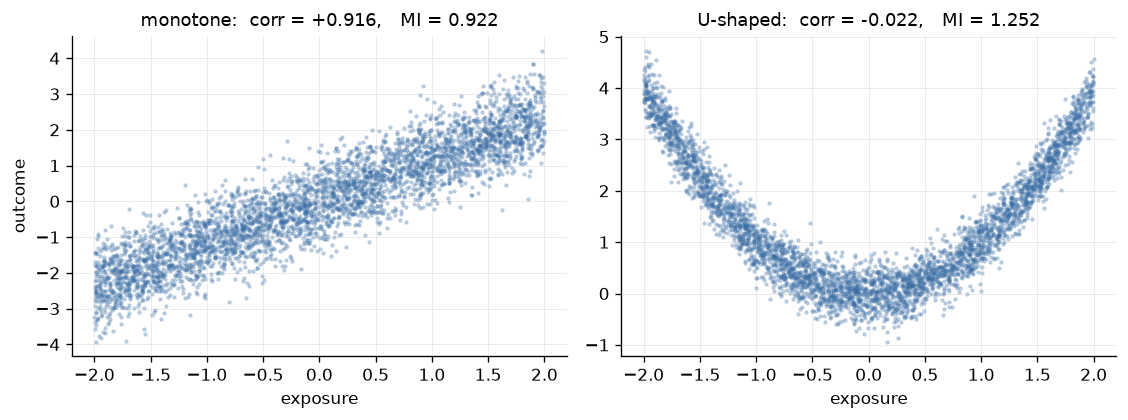

A screening step ranking exposures by |correlation| discards the U-shaped one;
ranking by mutual information keeps it. Relevant to 5.1 and the case studies.


In [22]:
# Why MI and not correlation: a U-shaped exposure-response.
n_u = 4000
x_u = rng.uniform(-2, 2, n_u)
y_lin = 1.2 * x_u + rng.normal(0, 0.6, n_u)
y_u = x_u**2 + rng.normal(0, 0.3, n_u)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.6), sharex=True)
for ax, yy, name in zip(axes, [y_lin, y_u], ["monotone", "U-shaped"]):
    ax.scatter(x_u, yy, s=3, alpha=0.25, color=nk.PALETTE["pos"])
    r = np.corrcoef(x_u, yy)[0, 1]
    mi = mutual_info_hist(x_u, yy, bins=32)
    ax.set_title(f"{name}:  corr = {r:+.3f},   MI = {mi:.3f}")
    ax.set_xlabel("exposure")
axes[0].set_ylabel("outcome")
plt.tight_layout(); plt.show()

print("A screening step ranking exposures by |correlation| discards the U-shaped one;")
print("ranking by mutual information keeps it. Relevant to 5.1 and the case studies.")

### Try it 9. When would you screen on MI instead of correlation?

The two panels have similar mutual information but wildly different correlations.

1. Describe the U-shaped panel as a dose-response relationship an epidemiologist might actually meet.
2. MI is always $\ge 0$ and the histogram estimator is biased *upward*. What does that imply about ranking 200 exposures by estimated MI when most are null?
3. Given (2), would you use MI as a screening filter, as a final answer, or neither? One sentence.

**Your answer**

*(write here)*

## What can we conclude?

Every fact in this notebook was stated and then checked, and the checks are the point. Here is where each one is next used.

| Fact established here | First needed in |
|---|---|
| $\lVert u-v\rVert^2$ from inner products alone | NB-1, §1.2 — the kernel trick |
| PSD $\Leftrightarrow$ Cholesky exists; jitter as noise | every GP routine from NB-2 onward |
| $\log\det$ via Cholesky, never via `det` | NB-2, §2.4 — the marginal likelihood |
| $\operatorname{tr}(ABC)$ is cyclic | NB-2, §2.4 — its gradient |
| Chain rule for log-parameterisation | NB-2 §2.4, NB-4 §4.5 |
| Duality and complementary slackness | NB-1, §1.1 — why SVMs are sparse |
| **The Gaussian conditioning formula** | **NB-2, §2.2 — the core of GP regression** |
| Precisions add | NB-4, §4.5 — shrinkage priors |
| KL is asymmetric and mode-seeking | NB-7, §7.2 — variational inference |
| $\hat{R}$, ESS, and their blind spots | NB-5 §5.3, NB-7 §7.3 |
| MI sees nonlinearity, correlation does not | NB-5, §5.1 — screening |

The one idea to carry forward above all others is §0.6. A Gaussian process is that formula with the covariance supplied by a kernel — nothing more.

## What should you submit?

Before saving your copy, check that you have done the following.

- Run every code cell from top to bottom.
- Written something in your own words in **Try it 1–9**.
- Changed at least one setting — a lengthscale in §0.2, a step size in §0.9, the bin count in §0.10 — and written down what changed and why.
- Stated, without looking back, what the Gaussian conditioning formula computes.

**Going further (optional)**

1. Show numerically that $\Sigma_{11} - \Sigma_{12}\Sigma_{22}^{-1}\Sigma_{21} \preceq \Sigma_{11}$: conditioning never increases variance.
2. Verify the Woodbury identity on random matrices. It is what makes sparse GPs (§2.5) and random Fourier features (§7.1) cheap.
3. Make the Metropolis proposal adapt its step size during warm-up to hit 30% acceptance, and confirm the ESS improves.
4. Replace the histogram MI estimator with a $k$-nearest-neighbour one and compare the bias at $n < 500$.

*NB-1 turns the inner product of §0.1 into a kernel, and the duality of §0.5 into a support vector machine.*